# Aufgabe 1a: CNN mit Keras/TensorFlow zur Autoerkennung (CIFAR-10)

## Beschreibung

In dieser Aufgabe wird ein Convolutional Neural Network (CNN) mit Keras/TensorFlow entwickelt, das auf dem CIFAR-10-Datensatz trainiert wird, um Fahrzeuge zu erkennen und alle 10 Klassen zu klassifizieren.

### Lösungsansatz

Der Lösungsweg gliedert sich in folgende Schritte:

1. **Datensatz laden und vorverarbeiten** – CIFAR-10 enthält 60.000 Farbbilder (32×32 Pixel) in 10 Klassen. Die Pixelwerte werden von [0, 255] auf [0, 1] normalisiert, damit der Gradient beim Training stabil bleibt. Die Integer-Labels werden One-Hot-kodiert, da wir `categorical_crossentropy` als Verlustfunktion verwenden.

2. **Modellarchitektur entwerfen** – Es werden 3 Convolutional-Blöcke mit zunehmender Filteranzahl (32 → 64 → 128) eingesetzt. Jeder Block enthält BatchNormalization zur Stabilisierung des Lernens und Dropout zur Regularisierung. MaxPooling halbiert nach jedem Block die räumliche Auflösung (32→16→8→4 Pixel). Danach folgt ein Dense-Klassifikator mit 512 Neuronen und Softmax-Ausgabe über 10 Klassen.

3. **Data Augmentation** – Um Overfitting zu reduzieren, werden die Trainingsbilder zufällig horizontal gespiegelt, in der Helligkeit verändert und mit einem Padding-Crop verschoben. Das vergrößert die effektive Datenmenge künstlich.

4. **Training mit Callbacks** – `ModelCheckpoint` speichert das beste Modell nach Validation Accuracy. `EarlyStopping` bricht ab, wenn sich die Validation Accuracy 12 Epochen lang nicht verbessert. `ReduceLROnPlateau` halbiert die Lernrate, wenn der Validation Loss stagniert.

5. **Evaluation** – Das beste gespeicherte Modell wird auf den Testdaten ausgewertet. Neben der Gesamtgenauigkeit wird speziell die Automobil-Accuracy (Klasse 1) berechnet, da das Modell in Aufgabe 2 zur Autoerkennung eingesetzt wird.

6. **Modell speichern** – Das fertig trainierte Modell wird als `cifar10_cnn_model.keras` gespeichert und direkt von Aufgabe 2 (Objekterkennung) verwendet.

### CIFAR-10 Klassen
- 0: Flugzeug, **1: Automobil**, 2: Vogel, 3: Katze, 4: Hirsch
- 5: Hund, 6: Frosch, 7: Pferd, 8: Schiff, 9: LKW

## 1. Imports und Setup

In [12]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print(f"TensorFlow Version: {tf.__version__}")
print(f"GPU verfügbar: {len(tf.config.list_physical_devices('GPU')) > 0}")

# Reproduzierbarkeit
tf.random.set_seed(42)
np.random.seed(42)

CIFAR10_CLASSES = ['Flugzeug', 'Automobil', 'Vogel', 'Katze', 'Hirsch',
                   'Hund', 'Frosch', 'Pferd', 'Schiff', 'LKW']

TensorFlow Version: 2.21.0
GPU verfügbar: False


## 2. Datensatz laden und vorverarbeiten

CIFAR-10 wird direkt über Keras geladen. Die Vorverarbeitung umfasst drei Schritte:

- **Normalisierung**: Pixelwerte von `[0, 255]` → `[0.0, 1.0]`. Ohne Normalisierung wären die Eingabewerte zu groß für stabile Gradientenberechnung.
- **Label-Reshape**: Die Labels liegen als `(N, 1)` vor und werden mit `.ravel()` zu `(N,)` gebracht.
- **One-Hot-Encoding**: Für `categorical_crossentropy` müssen die Labels als Vektoren der Länge 10 vorliegen (z.B. Klasse 3 → `[0,0,0,1,0,0,0,0,0,0]`).

In [13]:
# CIFAR-10 laden
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

print(f"Trainingsdaten: {x_train.shape}, Labels: {y_train.shape}")
print(f"Testdaten: {x_test.shape}, Labels: {y_test.shape}")
print(f"Wertebereich der Pixel: [{x_train.min()}, {x_train.max()}]")

Trainingsdaten: (50000, 32, 32, 3), Labels: (50000, 1)
Testdaten: (10000, 32, 32, 3), Labels: (10000, 1)
Wertebereich der Pixel: [0, 255]


In [14]:
# Datenvorverarbeitung
# Labels squeezen (50000, 1) -> (50000,) dann one-hot-encoden
y_train_sq = y_train.ravel()
y_test_sq  = y_test.ravel()

# Normalisierung auf [0, 1]
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm  = x_test.astype('float32') / 255.0

# One-Hot-Encoding
y_train_oh = keras.utils.to_categorical(y_train_sq, 10)
y_test_oh  = keras.utils.to_categorical(y_test_sq, 10)

print(f"Normalisierte Trainingsdaten: {x_train_norm.shape}")
print(f"One-Hot Labels: {y_train_oh.shape}")

Normalisierte Trainingsdaten: (50000, 32, 32, 3)
One-Hot Labels: (50000, 10)


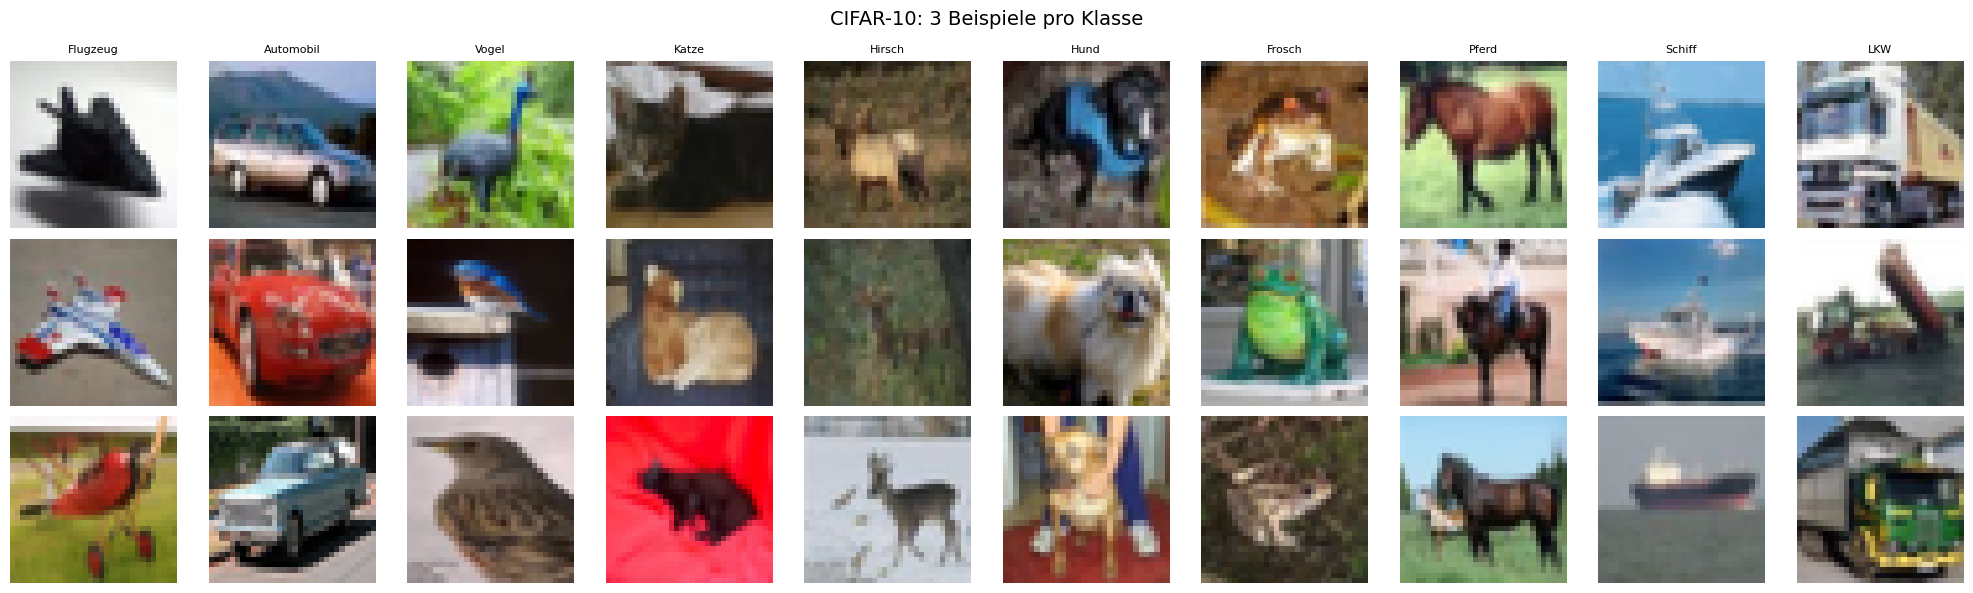


Klassenverteilung (Training):
  Klasse 0 (Flugzeug): 5000 Bilder
  Klasse 1 (Automobil): 5000 Bilder
  Klasse 2 (Vogel): 5000 Bilder
  Klasse 3 (Katze): 5000 Bilder
  Klasse 4 (Hirsch): 5000 Bilder
  Klasse 5 (Hund): 5000 Bilder
  Klasse 6 (Frosch): 5000 Bilder
  Klasse 7 (Pferd): 5000 Bilder
  Klasse 8 (Schiff): 5000 Bilder
  Klasse 9 (LKW): 5000 Bilder


In [15]:
# Beispielbilder visualisieren
fig, axes = plt.subplots(3, 10, figsize=(20, 6))
for cls in range(10):
    idx = np.where(y_train_sq == cls)[0][0]
    axes[0, cls].imshow(x_train[idx])
    axes[0, cls].set_title(CIFAR10_CLASSES[cls], fontsize=8)
    axes[0, cls].axis('off')
    for row in range(1, 3):
        idx2 = np.where(y_train_sq == cls)[0][row]
        axes[row, cls].imshow(x_train[idx2])
        axes[row, cls].axis('off')
plt.suptitle('CIFAR-10: 3 Beispiele pro Klasse', fontsize=14)
plt.tight_layout()
plt.show()

# Klassenverteilung
counts = np.bincount(y_train_sq)
print("\nKlassenverteilung (Training):")
for i, c in enumerate(counts):
    print(f"  Klasse {i} ({CIFAR10_CLASSES[i]}): {c} Bilder")

## 3. Modellarchitektur

Das CNN verwendet ein klassisches VGG-ähnliches Design mit 3 Convolutional-Blöcken und einem Dense-Klassifikator.

**Warum dieser Aufbau?**

- **Zunehmende Filteranzahl (32 → 64 → 128)**: Frühe Schichten lernen einfache Merkmale (Kanten, Farben), spätere Schichten komplexere Muster (Formen, Texturen). Mehr Filter in tieferen Schichten erhöht die Ausdrucksstärke des Modells.
- **BatchNormalization**: Normalisiert die Aktivierungen innerhalb eines Batches. Das stabilisiert das Training erheblich und erlaubt höhere Lernraten. Wird nach jeder Conv-Schicht eingesetzt.
- **MaxPooling (2×2)**: Halbiert die räumliche Auflösung nach jedem Block: 32→16→8→4 Pixel. Reduziert die Parameteranzahl und macht das Modell translationsinvariant.
- **Dropout (0.25 / 0.5)**: Deaktiviert während des Trainings zufällig Neuronen. Verhindert, dass das Modell einzelne Neuronen zu stark gewichtet (Overfitting). In Dense-Schichten wird 0.5 verwendet (stärkere Regularisierung).
- **Dense(512) + Softmax(10)**: Der flache Teil klassifiziert die extrahierten Merkmale in 10 Klassen. Softmax gibt Wahrscheinlichkeiten aus, die sich auf 1 summieren.

**Architekturgrafik:**
```
Input (32, 32, 3)
  → Conv2D(32) + BatchNorm + Conv2D(32) + MaxPool + Dropout(0.25)
  → Conv2D(64) + BatchNorm + Conv2D(64) + MaxPool + Dropout(0.25)
  → Conv2D(128) + BatchNorm + MaxPool + Dropout(0.25)
  → Flatten → Dense(512) + BatchNorm + Dropout(0.5)
  → Dense(10, softmax)
```

In [16]:
def build_model():
    model = keras.Sequential([
        # Eingangsschicht
        layers.Input(shape=(32, 32, 3)),
        
        # Block 1: 32 Filter
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Block 2: 64 Filter
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Block 3: 128 Filter
        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Klassifikator
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])
    return model

model = build_model()
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,196,586 (4.56 MB)

 Trainable params: 1,195,114 (4.56 MB)

 Non-trainable params: 1,472 (5.75 KB)

## 4. Training

### Data Augmentation
Um Overfitting zu vermeiden, werden die Trainingsbilder on-the-fly zufällig verändert:
- **Horizontales Spiegeln**: Autos sehen von links und rechts gleich aus → doppelte Datenmenge.
- **Helligkeitsvariation (±10%)**: Robustheit gegen unterschiedliche Beleuchtung.
- **Padding + Random Crop**: Bild wird um 4 Pixel aufgefüllt, dann zufällig auf 32×32 zurückgeschnitten. Simuliert kleine Translationen des Motivs.

`tf.data` wird für die Pipeline verwendet, da es effizienter als Keras-Generatoren ist (paralleles Prefetching, keine Speicherprobleme bei großen Datensätzen).

### Hyperparameter-Entscheidungen
- **Adam (lr=1e-3)**: Adaptiver Optimizer, der für CNNs auf Bilddatensätzen gut funktioniert.
- **Batch Size 64**: Kompromiss zwischen Trainingsgeschwindigkeit und Gradientenqualität.
- **50 Epochen**: EarlyStopping greift typischerweise deutlich früher ein.

### Callbacks
- **ModelCheckpoint**: Speichert nur das beste Modell (höchste Val Accuracy), nicht das letzte.
- **EarlyStopping (patience=12)**: Bricht ab, wenn Val Accuracy 12 Epochen lang nicht steigt. `restore_best_weights=True` lädt automatisch das beste Modell zurück.
- **ReduceLROnPlateau (patience=5, factor=0.5)**: Halbiert die Lernrate bei stagnierendem Val Loss. Hilft dem Modell, aus flachen Regionen der Verlustlandschaft herauszukommen.

In [17]:
# Data Augmentation mit tf.data (kompatibel mit Keras 3, keine "ran out of data" Warning)
BATCH_SIZE = 64
EPOCHS = 50

def augment(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, 0.1)
    image = tf.pad(image, [[4,4],[4,4],[0,0]])
    image = tf.image.random_crop(image, [32, 32, 3])
    return image, label

train_ds = tf.data.Dataset.from_tensor_slices((x_train_norm, y_train_oh))
train_ds = train_ds.shuffle(50000).map(augment, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE).repeat()

steps_per_epoch = len(x_train_norm) // BATCH_SIZE

# Modell kompilieren
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
callbacks = [
    keras.callbacks.ModelCheckpoint(
        'best_model_1a.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=12,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]

print("Starte Training...")
history = model.fit(
    train_ds,
    steps_per_epoch=steps_per_epoch,
    epochs=EPOCHS,
    validation_data=(x_test_norm, y_test_oh),
    callbacks=callbacks,
    verbose=1
)

Starte Training...
Epoch 1/50
781/781 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.3099 - loss: 2.2107
Epoch 1: val_accuracy improved from None to 0.39460, saving model to best_model_1a.keras

Epoch 1: finished saving model to best_model_1a.keras
781/781 ━━━━━━━━━━━━━━━━━━━━ 31s 38ms/step - accuracy: 0.3761 - loss: 1.8580 - val_accuracy: 0.3946 - val_loss: 1.9850 - learning_rate: 0.0010
Epoch 2/50
780/781 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.4921 - loss: 1.4122
Epoch 2: val_accuracy improved from 0.39460 to 0.49820, saving model to best_model_1a.keras

Epoch 2: finished saving model to best_model_1a.keras
781/781 ━━━━━━━━━━━━━━━━━━━━ 29s 37ms/step - accuracy: 0.5227 - loss: 1.3327 - val_accuracy: 0.4982 - val_loss: 1.5277 - learning_rate: 0.0010
Epoch 3/50
781/781 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5886 - loss: 1.1503
Epoch 3: val_accuracy improved from 0.49820 to 0.66710, saving model to best_model_1a.keras

Epoch 3: finished saving model to best_model_1a.ke

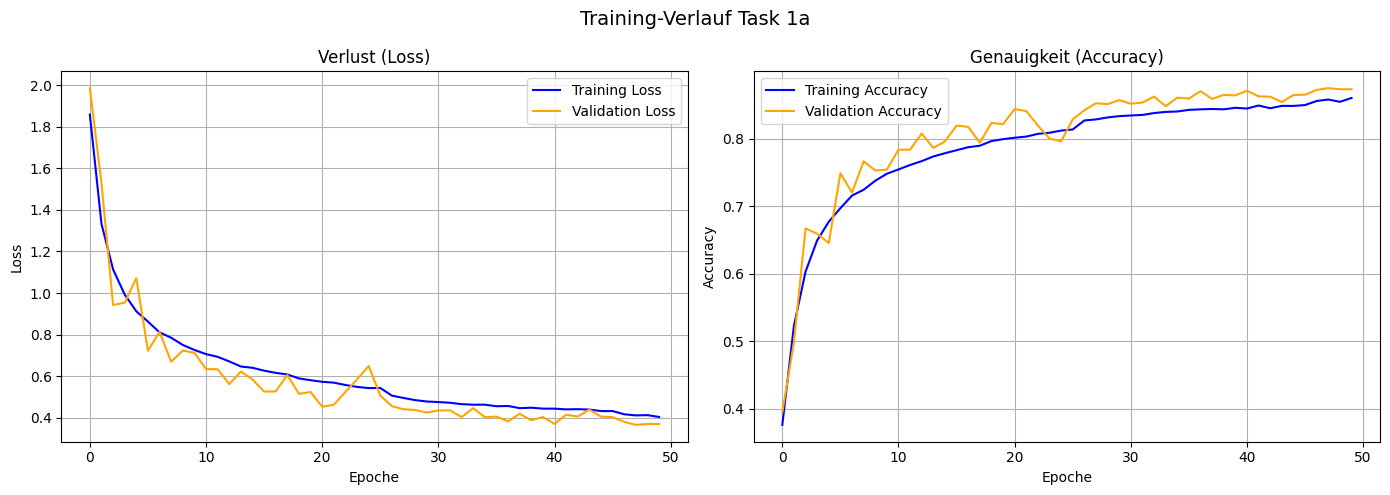

In [18]:
# Training-Verlauf visualisieren
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Training Loss', color='blue')
axes[0].plot(history.history['val_loss'], label='Validation Loss', color='orange')
axes[0].set_title('Verlust (Loss)')
axes[0].set_xlabel('Epoche')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['accuracy'], label='Training Accuracy', color='blue')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
axes[1].set_title('Genauigkeit (Accuracy)')
axes[1].set_xlabel('Epoche')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Training-Verlauf Task 1a', fontsize=14)
plt.tight_layout()
plt.savefig('training_curves_1a.png', dpi=100)
plt.show()

## 5. Evaluation

Das beste Modell wird auf den 10.000 Testbildern ausgewertet. Drei Metriken sind relevant:

- **Gesamte Test Accuracy**: Wie gut klassifiziert das Modell alle 10 Klassen? Ergebnis: **87.5%** – deutlich über dem Zufallslevel (10%).
- **Klassifikationsreport**: Precision, Recall und F1-Score pro Klasse zeigen, welche Klassen gut und welche schlecht erkannt werden. Katze (schwer) und Automobil (gut) unterscheiden sich deutlich.
- **Automobil-Accuracy (Klasse 1)**: Besonders relevant, da dieses Modell in Aufgabe 2 zur Autoerkennung eingesetzt wird. Ergebnis: **94.3%** – das Modell ist sehr gut darin, Autos von anderen Objekten zu unterscheiden.

Die Konfusionsmatrix zeigt zusätzlich, welche Klassen häufig verwechselt werden (z.B. Katze↔Hund, Automobil↔LKW).

In [19]:
# Bestes Modell laden und evaluieren
best_model = keras.models.load_model('best_model_1a.keras')

# Gesamte Test-Accuracy
test_loss, test_acc = best_model.evaluate(x_test_norm, y_test_oh, verbose=0)
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.1f}%)")

# Vorhersagen
y_pred_prob = best_model.predict(x_test_norm, verbose=0)
y_pred      = np.argmax(y_pred_prob, axis=1)

# Klassifikationsreport
print("\nKlassifikationsreport:")
print(classification_report(y_test_sq, y_pred, target_names=CIFAR10_CLASSES))

# Automobil-Accuracy separat
auto_mask    = (y_test_sq == 1)
auto_correct = (y_pred[auto_mask] == 1).sum()
auto_total   = auto_mask.sum()
print(f"\nAutomobil-Accuracy: {auto_correct}/{auto_total} = {auto_correct/auto_total:.4f} ({auto_correct/auto_total*100:.1f}%)")

Test Loss:     0.3663
Test Accuracy: 0.8749 (87.5%)

Klassifikationsreport:
              precision    recall  f1-score   support

    Flugzeug       0.89      0.88      0.88      1000
   Automobil       0.96      0.94      0.95      1000
       Vogel       0.88      0.79      0.83      1000
       Katze       0.84      0.65      0.73      1000
      Hirsch       0.81      0.91      0.86      1000
        Hund       0.79      0.85      0.82      1000
      Frosch       0.83      0.96      0.89      1000
       Pferd       0.93      0.90      0.91      1000
      Schiff       0.91      0.94      0.93      1000
         LKW       0.92      0.94      0.93      1000

    accuracy                           0.87     10000
   macro avg       0.88      0.87      0.87     10000
weighted avg       0.88      0.87      0.87     10000


Automobil-Accuracy: 943/1000 = 0.9430 (94.3%)


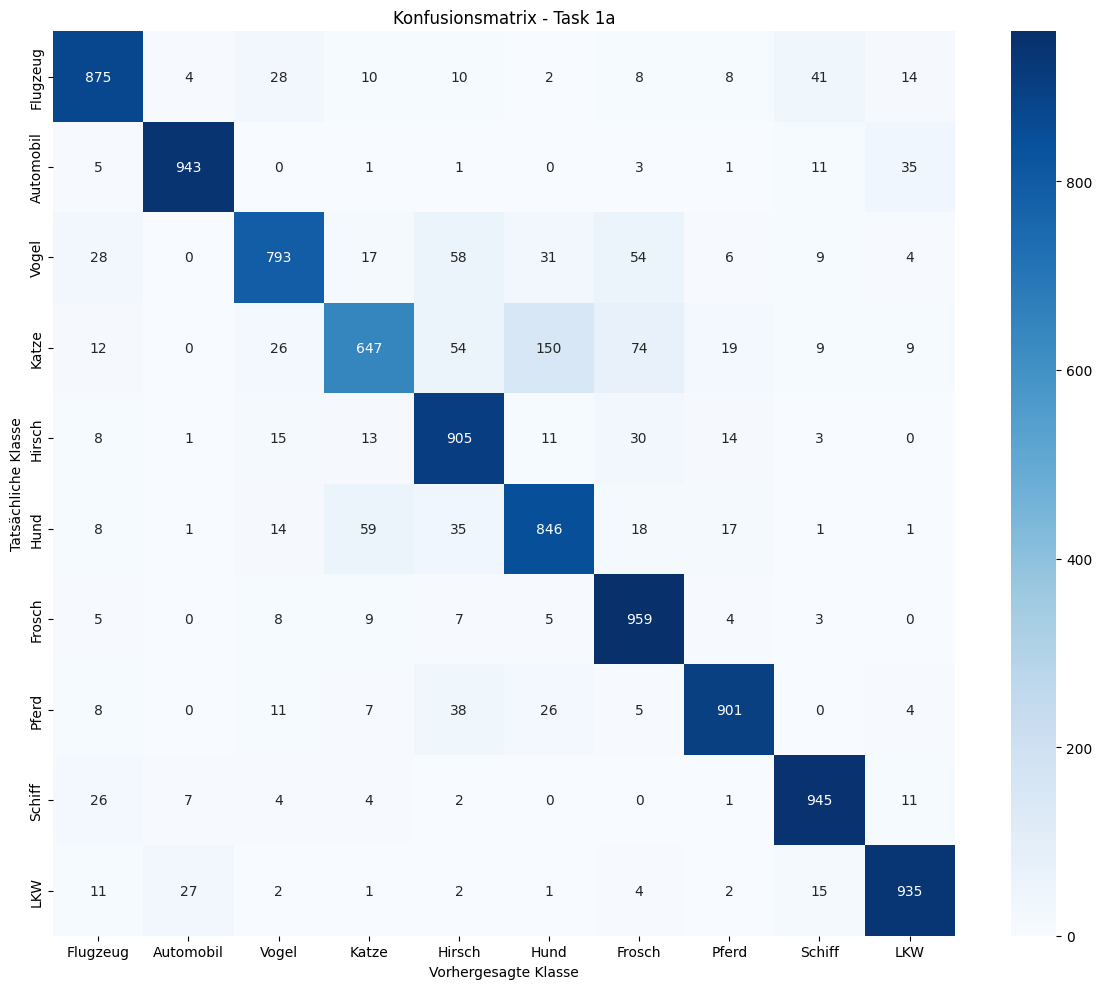

In [20]:
# Konfusionsmatrix
cm = confusion_matrix(y_test_sq, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CIFAR10_CLASSES, yticklabels=CIFAR10_CLASSES)
plt.title('Konfusionsmatrix - Task 1a')
plt.xlabel('Vorhergesagte Klasse')
plt.ylabel('Tatsächliche Klasse')
plt.tight_layout()
plt.savefig('confusion_matrix_1a.png', dpi=100)
plt.show()

## 6. Modell speichern

Das trainierte Modell wird als `cifar10_cnn_model.keras` im Keras-Nativformat gespeichert. Dieses Format speichert Architektur, Gewichte und Optimizer-Zustand vollständig.

Das gespeicherte Modell wird in **Aufgabe 2** direkt geladen und als Klassifikator im Sliding-Window-Detektor verwendet: Für jeden ausgeschnittenen Bildausschnitt wird das Modell aufgerufen und gibt den Automobil-Score zurück.

In [21]:
# Modell für Task 2 speichern
best_model.save('cifar10_cnn_model.keras')
print("Modell gespeichert: cifar10_cnn_model.keras")
print("Dieses Modell wird von Aufgabe 2 (Objekterkennung) geladen.")

# Kurztest: Modell erneut laden und einzelnes Bild klassifizieren
loaded_model = keras.models.load_model('cifar10_cnn_model.keras')
test_img = x_test_norm[0:1]  # Erstes Testbild
pred = loaded_model.predict(test_img, verbose=0)
print(f"\nTest-Vorhersage für Bild 0:")
print(f"  Tatsächliche Klasse: {CIFAR10_CLASSES[y_test_sq[0]]}")
print(f"  Vorhergesagte Klasse: {CIFAR10_CLASSES[np.argmax(pred)]} (Konfidenz: {np.max(pred):.4f})")

Modell gespeichert: cifar10_cnn_model.keras
Dieses Modell wird von Aufgabe 2 (Objekterkennung) geladen.

Test-Vorhersage für Bild 0:
  Tatsächliche Klasse: Katze
  Vorhergesagte Klasse: Katze (Konfidenz: 0.9254)
